# FPS Coverage Analysis — Iteration 1 / Split 17
| Group | N | Meaning |
|---|---|---|
| **T** | 16 | Training structures (`mace_fps_split17` seed) |
| **FPS_other** | varies | FPS picks from MD pool |
| **FPS_burov_tests / FPS_burov_MD** | varies | FPS picks from Rajdeep's structures |
| **pool** | ~1200 | MD structures from split-17 model |
| **burov_tests / burov_MD** | 10 each | Rajdeep's unselected structures |
| **case3** | 1 | Case3 VASP structure |

## 1. Imports & Config

In [1]:
import json, os
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

np.random.seed(42)

POOL_JSON = ("/home/mehuldarak/athena/structure_level_latents/"
             "iteration0_mace_latents/it0_split17_structure_latents.json")
SEED_JSON = ("/home/mehuldarak/athena/structure_level_latents/"
             "iteration0_mace_latents/it0_TrainingEmbs_split17_structure_latents.json")
EXTRA_JSONS = {
    "burov_tests": ("/home/mehuldarak/athena/structure_level_latents/"
                    "iteration0_mace_latents/burov_tests_mace_ft_split17.json"),
    "burov_MD":    ("/home/mehuldarak/athena/structure_level_latents/"
                    "iteration0_mace_latents/burov_MD_mace_ft_split17.json"),
    "case3":       ("/home/mehuldarak/athena/structure_level_latents/"
                    "iteration0_mace_latents/case3_mace_ft_split17.json"),
}
OUTPUT_DIR = "/home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_FPS        = 20
N_SUPER      = 6
USE_PCA      = True
PCA_VAR      = 0.95
PCA_MIN_DIMS = 32
ALL_EXTRA    = ("burov_tests", "burov_MD", "case3")
EXTRA_NO_C3  = ("burov_tests", "burov_MD")
ALL_FPS_LABELS = ("FPS_other", "FPS_burov_tests", "FPS_burov_MD")

print("Config ready →", OUTPUT_DIR)


Config ready → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17


## 2. Load Latents

In [2]:
with open(POOL_JSON) as f: pool_data = json.load(f)
with open(SEED_JSON) as f: seed_data = json.load(f)
print(f"Pool : {len(pool_data)} | Seed (T) : {len(seed_data)}")

extra_data = {}
for tag, jpath in EXTRA_JSONS.items():
    with open(jpath) as f:
        raw = json.load(f)
    for k, v in raw.items():
        key = f"{tag}__{os.path.basename(k)}"   # unique across groups
        extra_data[key] = {"vec": v, "group": tag, "stem": os.path.basename(k)}
    print(f"  {tag}: {len(raw)} structures")
print(f"Total extra: {len(extra_data)}")


Pool : 1200 | Seed (T) : 16
  burov_tests: 10 structures
  burov_MD: 10 structures
  case3: 1 structures
Total extra: 21


## 3. Build Unified Arrays

In [3]:
seed_basenames = {os.path.basename(k) for k in seed_data}
filenames, labels_raw, emb_list = [], [], []

for k, v in seed_data.items():
    filenames.append(k); labels_raw.append("T"); emb_list.append(v)

for k, v in pool_data.items():
    if os.path.basename(k) in seed_basenames: continue
    filenames.append(k); labels_raw.append("pool"); emb_list.append(v)

for key, info in extra_data.items():
    filenames.append(key)
    labels_raw.append(info["group"])
    emb_list.append(info["vec"])

labels_arr = np.array(labels_raw)
embeddings  = np.array(emb_list, dtype=np.float32)
print(pd.Series(labels_arr).value_counts().to_string())
print(f"Latent dim: {embeddings.shape[1]}")


pool           1200
T                16
burov_tests      10
burov_MD         10
case3             1
Latent dim: 256


## 4. L2 Normalise + PCA

In [4]:
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1
emb_norm = (embeddings / norms).astype(np.float32)

if USE_PCA:
    cumvar = np.cumsum(PCA().fit(emb_norm).explained_variance_ratio_)
    n_comp = max(PCA_MIN_DIMS, int(np.searchsorted(cumvar, PCA_VAR)) + 1)
    print(f"PCA → {n_comp} components ({PCA_VAR*100:.0f}% var)")
    emb_hd = PCA(n_components=n_comp).fit_transform(emb_norm).astype(np.float32)
else:
    emb_hd = emb_norm

pca2   = PCA(n_components=2).fit(emb_norm)
emb_2d = pca2.transform(emb_norm)
var_2d = pca2.explained_variance_ratio_ * 100
print(f"2D PCA: PC1={var_2d[0]:.1f}%  PC2={var_2d[1]:.1f}%")


PCA → 32 components (95% var)
2D PCA: PC1=96.4%  PC2=1.9%


## 5. Group Indices

In [5]:
ALL_GROUPS = ("T", "pool") + ALL_EXTRA
idx   = {lbl: np.where(labels_arr == lbl)[0] for lbl in ALL_GROUPS}
emb_T = emb_hd[idx["T"]]
print("Group sizes:", {g: len(v) for g, v in idx.items()})


Group sizes: {'T': 16, 'pool': 1200, 'burov_tests': 10, 'burov_MD': 10, 'case3': 1}


## 6. Greedy FPS
**Seed** = T (16) | **Candidates** = MD pool + burov_tests + burov_MD

In [6]:
def greedy_fps(pool_embs, seed_embs, n_select):
    D = cdist(pool_embs, seed_embs, metric="euclidean")
    min_dist = D.min(axis=1).copy()
    selected = []
    for _ in range(n_select):
        pick = int(np.argmax(min_dist))
        selected.append(pick)
        d_new = np.linalg.norm(pool_embs - pool_embs[pick], axis=1)
        min_dist = np.minimum(min_dist, d_new)
        min_dist[pick] = -np.inf
    return np.array(selected)

fps_candidate_idx  = np.concatenate([idx["pool"], idx["burov_tests"], idx["burov_MD"]])
fps_local_idx      = greedy_fps(emb_hd[fps_candidate_idx], emb_T, N_FPS)
fps_global_idx     = fps_candidate_idx[fps_local_idx]

print(f"FPS seed:       T ({len(idx['T'])})")
print(f"FPS candidates: pool({len(idx['pool'])}) + burov_tests({len(idx['burov_tests'])}) "
      f"+ burov_MD({len(idx['burov_MD'])}) = {len(fps_candidate_idx)}")
print(f"\nSelected {len(fps_global_idx)} structures:")
for i, gi in enumerate(fps_global_idx):
    print(f"  {i+1:2d}. [{labels_arr[gi]:<12}]  {os.path.basename(filenames[gi])}")


FPS seed:       T (16)
FPS candidates: pool(1200) + burov_tests(10) + burov_MD(10) = 1220

Selected 20 structures:
   1. [burov_tests ]  burov_tests__Li_LLZO_110_ct-Li5La2Zr4O8_opp-Li3La2O10_side-bottom_var01.cif
   2. [burov_tests ]  burov_tests__Li_LLZO_011_ct-Li6La4O9_opp-Li3La1O5_side-bottom_var01.cif
   3. [burov_MD    ]  burov_MD__Li_LLZO_110_ct-Li1Zr1O2_opp-Li7La4O6_side-bottom_var01.cif
   4. [pool        ]  Li_100_slab__LLZO_011_La_code71_sto_bestgap_3.00A_r_T550K_1600.cif
   5. [pool        ]  Li_100_slab__LLZO_110_Li_order17_off_bestgap_2.50A_r_T1100K_100.cif
   6. [pool        ]  Li_111_slab__LLZO_110_Zr_bestgap_2.50A_r_T1100K_4700.cif
   7. [pool        ]  Li_110_slab__LLZO_010_La_order0_off_bestgap_2.00A_r_T1100K_2800.cif
   8. [pool        ]  Li_100_slab__LLZO_010_La_order0_off_bestgap_2.50A_r_T1100K_4800.cif
   9. [pool        ]  Li_110_slab__LLZO_011_La_code71_sto_bestgap_2.50A_r_T550K_2800.cif
  10. [burov_MD    ]  burov_MD__Li_LLZO_011_ct-Li2La1Zr2O4_opp-Li2La1O4_sid

## 7. Style Config

In [7]:
# --- NEW LABEL LOGIC (force clear FPS_burov visibility) ---

labels_plot = labels_arr.copy()

# Track explicitly
fps_burov_tests_idx = []
fps_burov_md_idx    = []
fps_other_idx       = []

for gi in fps_global_idx:
    orig = labels_arr[gi]

    if orig == "burov_tests":
        labels_plot[gi] = "FPS_burov_tests"
        fps_burov_tests_idx.append(gi)

    elif orig == "burov_MD":
        labels_plot[gi] = "FPS_burov_MD"
        fps_burov_md_idx.append(gi)

    else:
        labels_plot[gi] = "FPS_other"
        fps_other_idx.append(gi)

# Convert to arrays
fps_burov_tests_idx = np.array(fps_burov_tests_idx, dtype=int)
fps_burov_md_idx    = np.array(fps_burov_md_idx, dtype=int)
fps_other_idx       = np.array(fps_other_idx, dtype=int)

# Build plotting index dictionary
idx_plot = {
    "T": idx["T"],
    "pool": idx["pool"],
    "FPS_other": fps_other_idx,
    "FPS_burov_tests": fps_burov_tests_idx,
    "FPS_burov_MD": fps_burov_md_idx,
    "burov_tests": idx["burov_tests"],
    "burov_MD": idx["burov_MD"],
    "case3": idx["case3"],
}

# Debug print (IMPORTANT)
print("\n=== FPS SELECTION BREAKDOWN ===")
print(f"FPS_other         : {len(fps_other_idx)}")
print(f"FPS_burov_tests   : {len(fps_burov_tests_idx)}")
print(f"FPS_burov_MD      : {len(fps_burov_md_idx)}")


=== FPS SELECTION BREAKDOWN ===
FPS_other         : 15
FPS_burov_tests   : 3
FPS_burov_MD      : 2


## 8. Distances — All Groups → Nearest T

In [8]:
dist_pool = cdist(emb_hd[idx["pool"]], emb_T).min(axis=1)

def pool_pct(d_vals):
    return np.array([100.0*(dist_pool < d).sum()/len(dist_pool) for d in d_vals])

# Per FPS sub-label distances
dist_fps, pct_fps = {}, {}
for lbl in ALL_FPS_LABELS:
    gi_arr = idx_plot[lbl]
    if len(gi_arr):
        d = cdist(emb_hd[gi_arr], emb_T).min(axis=1)
        dist_fps[lbl] = d; pct_fps[lbl] = pool_pct(d)

# Combined for backwards compat (coverage metrics, super-reps)
dist_fps_other = cdist(emb_hd[fps_global_idx], emb_T).min(axis=1)
pct_fps_other  = pool_pct(dist_fps_other)

# Extra groups
dist_extra, pct_extra = {}, {}
for g in ALL_EXTRA:
    if not len(idx[g]): continue
    d = cdist(emb_hd[idx[g]], emb_T).min(axis=1)
    dist_extra[g] = d; pct_extra[g] = pool_pct(d)

print(f"pool          mean={dist_pool.mean():.4f}  median={np.median(dist_pool):.4f}")
for lbl in ALL_FPS_LABELS:
    if lbl in dist_fps:
        d = dist_fps[lbl]
        print(f"{lbl:<22} n={len(d)}  mean={d.mean():.4f}  mean_pct={pct_fps[lbl].mean():.1f}th")
for g in ALL_EXTRA:
    if g in dist_extra:
        d = dist_extra[g]
        print(f"{g:<22} mean={d.mean():.4f}  min={d.min():.4f}  "
              f"max={d.max():.4f}  mean_pct={pct_extra[g].mean():.1f}th")


pool          mean=0.0132  median=0.0135
FPS_other              n=15  mean=0.0168  mean_pct=81.1th
FPS_burov_tests        n=3  mean=0.0306  mean_pct=100.0th
FPS_burov_MD           n=2  mean=0.0247  mean_pct=100.0th
burov_tests            mean=0.0267  min=0.0210  max=0.0402  mean_pct=100.0th
burov_MD               mean=0.0252  min=0.0216  max=0.0328  mean_pct=100.0th
case3                  mean=0.1850  min=0.1850  max=0.1850  mean_pct=100.0th


## 9. FPS_other Coverage Table

In [9]:
df_fps = pd.DataFrame({
    "Stem":               [os.path.basename(filenames[gi]) for gi in fps_global_idx],
    "Origin":             [labels_arr[gi] for gi in fps_global_idx],
    "Dist_to_nearest_T":  dist_fps_other,
    "Percentile_vs_pool": pct_fps_other,
}).sort_values("Dist_to_nearest_T", ascending=False).reset_index(drop=True)
pd.set_option("display.max_rows", None); pd.set_option("display.max_colwidth", 80)
print(df_fps.to_string(index=False))


                                                                       Stem      Origin  Dist_to_nearest_T  Percentile_vs_pool
burov_tests__Li_LLZO_110_ct-Li5La2Zr4O8_opp-Li3La2O10_side-bottom_var01.cif burov_tests           0.040245          100.000000
    burov_tests__Li_LLZO_011_ct-Li6La4O9_opp-Li3La1O5_side-bottom_var01.cif burov_tests           0.029954          100.000000
       burov_MD__Li_LLZO_110_ct-Li1Zr1O2_opp-Li7La4O6_side-bottom_var01.cif    burov_MD           0.024679          100.000000
    burov_MD__Li_LLZO_011_ct-Li2La1Zr2O4_opp-Li2La1O4_side-bottom_var01.cif    burov_MD           0.024660          100.000000
    burov_tests__Li_LLZO_001_ct-Li5La1O8_opp-Li1La1Zr1O4_side-top_var01.cif burov_tests           0.021631          100.000000
         Li_100_slab__LLZO_011_La_code71_sto_bestgap_3.00A_r_T550K_1600.cif        pool           0.020356           99.916667
        Li_100_slab__LLZO_110_Li_order17_off_bestgap_2.50A_r_T1100K_100.cif        pool           0.019138     

## 10. Coverage Metrics

In [10]:
print("="*60)
print("  COVERAGE METRICS  —  mace_fps_split17 / Iteration 1")
print("="*60)

print("\n1. Pool Distance Stats")
for stat, val in [("Mean", dist_pool.mean()), ("Median", np.median(dist_pool)),
                  ("Std",  dist_pool.std()),  ("Min",  dist_pool.min()),
                  ("Max",  dist_pool.max())]:
    print(f"   {stat:<8}: {val:.4f}")
for p in [75, 90, 95, 99]:
    print(f"   {p}th pct : {np.percentile(dist_pool, p):.4f}")

print("\n2. Coverage Fraction at Fixed Radii")
print(f"   {'Radius':>8}  {'% Covered':>10}  {'N':>6}")
print("   "+"-"*28)
for r in [0.005,0.008,0.010,0.012,0.015,0.018,0.020,0.025]:
    n = (dist_pool<=r).sum()
    print(f"   {r:>8.4f}  {100*n/len(dist_pool):>9.1f}%  {n:>6d}")

print("\n3. External Groups vs Pool Envelope")
pool_max = dist_pool.max(); pool_p95 = np.percentile(dist_pool, 95)
print(f"   Pool ceiling: {pool_max:.4f}  |  Pool 95th: {pool_p95:.4f}")
for g in ALL_EXTRA:
    if g not in dist_extra: continue
    d = dist_extra[g]
    print(f"   {g}: N>{pool_max:.4f} = {(d>pool_max).sum()}/{len(d)},  "
          f"mean={d.mean():.4f}, gap_ratio={d.mean()/dist_pool.mean():.2f}x")

print("\n4. Hypothetical T+FPS Coverage Improvement")
emb_T_aug = np.vstack([emb_T, emb_hd[fps_global_idx]])
dist_aug   = cdist(emb_hd[idx["pool"]], emb_T_aug).min(axis=1)
print(f"   Before: mean={dist_pool.mean():.4f}  After: mean={dist_aug.mean():.4f}  "
      f"Reduction: {100*(1-dist_aug.mean()/dist_pool.mean()):.1f}%")
for r in [0.010, 0.012, 0.015]:
    b = 100*(dist_pool<=r).sum()/len(dist_pool)
    a = 100*(dist_aug<=r).sum()/len(dist_aug)
    print(f"   r={r:.3f}: {b:.1f}% → {a:.1f}%  (+{a-b:.1f}pp)")
print("="*60)


  COVERAGE METRICS  —  mace_fps_split17 / Iteration 1

1. Pool Distance Stats
   Mean    : 0.0132
   Median  : 0.0135
   Std     : 0.0034
   Min     : 0.0027
   Max     : 0.0204
   75th pct : 0.0157
   90th pct : 0.0175
   95th pct : 0.0183
   99th pct : 0.0194

2. Coverage Fraction at Fixed Radii
     Radius   % Covered       N
   ----------------------------
     0.0050        0.8%      10
     0.0080        9.5%     114
     0.0100       17.6%     211
     0.0120       32.9%     395
     0.0150       66.8%     801
     0.0180       93.5%    1122
     0.0200       99.9%    1199
     0.0250      100.0%    1200

3. External Groups vs Pool Envelope
   Pool ceiling: 0.0204  |  Pool 95th: 0.0183
   burov_tests: N>0.0204 = 10/10,  mean=0.0267, gap_ratio=2.02x
   burov_MD: N>0.0204 = 10/10,  mean=0.0252, gap_ratio=1.91x
   case3: N>0.0204 = 1/1,  mean=0.1850, gap_ratio=14.01x

4. Hypothetical T+FPS Coverage Improvement
   Before: mean=0.0132  After: mean=0.0074  Reduction: 43.6%
   r=0.010:

## 11. Plot 1 — PCA Scatter + Histogram  (with Case3)

[INFO] STYLE not found → reinitializing


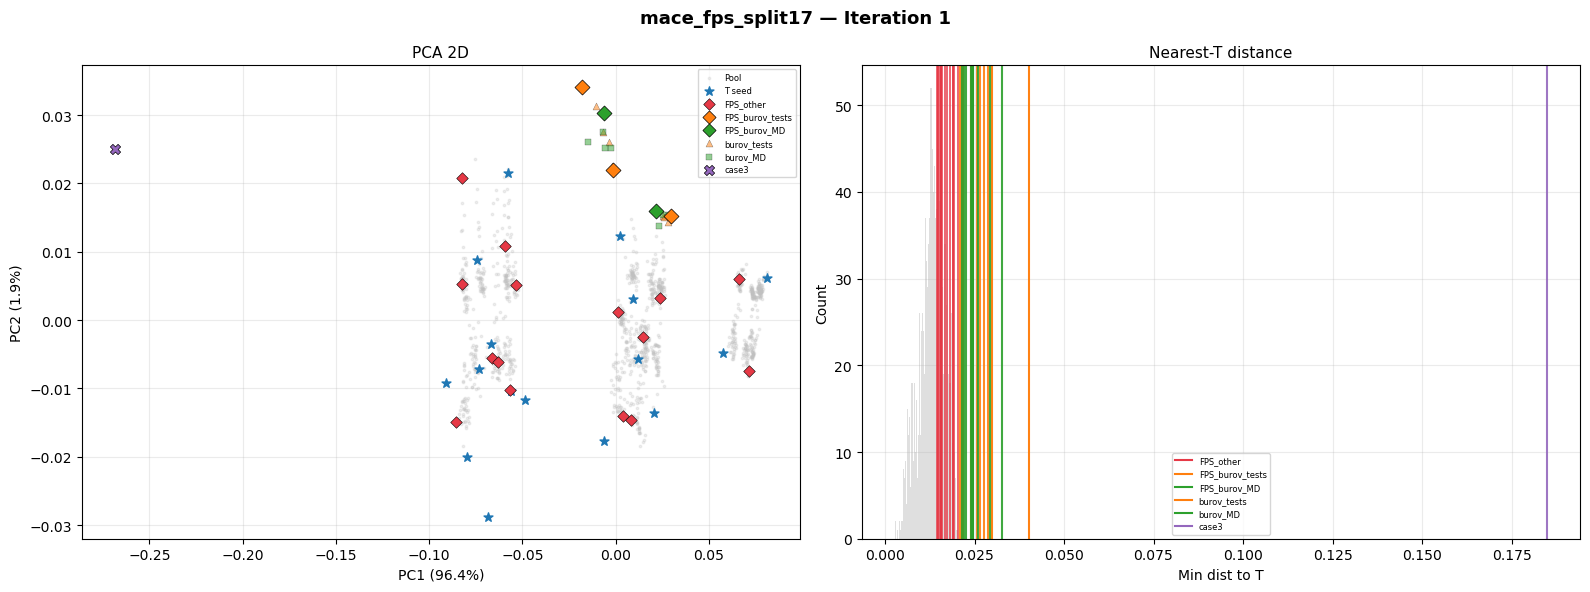

Saved → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17/it1_split17_coverage_overview_FIXED.png


In [12]:
# %% [markdown]
# ## 11. Plot 1 — PCA Scatter + Histogram  (with Case3)
# --- SAFETY: ensure STYLE exists ---
if "STYLE" not in globals():
    print("[INFO] STYLE not found → reinitializing")

    STYLE = {
        "pool": dict(c="#C0C0C0", marker="o", s=3, alpha=0.25, zorder=1, label="Pool"),
        "T": dict(c="#1F77B4", marker="*", s=45, alpha=1.00, zorder=5, label="T seed"),
        "FPS_other": dict(c="#E63946", marker="D", s=35, alpha=1.00, zorder=7,
                          edgecolors="k", linewidths=0.4, label="FPS_other"),
        "FPS_burov_tests": dict(c="#FF7F0E", marker="D", s=45, alpha=1.00, zorder=8,
                                edgecolors="k", linewidths=0.5, label="FPS_burov_tests"),
        "FPS_burov_MD": dict(c="#2CA02C", marker="D", s=45, alpha=1.00, zorder=8,
                             edgecolors="k", linewidths=0.5, label="FPS_burov_MD"),
        "burov_tests": dict(c="#FF7F0E", marker="^", s=25, alpha=0.50, zorder=4,
                            edgecolors="k", linewidths=0.3, label="burov_tests"),
        "burov_MD": dict(c="#2CA02C", marker="s", s=22, alpha=0.50, zorder=4,
                         edgecolors="k", linewidths=0.3, label="burov_MD"),
        "case3": dict(c="#9467BD", marker="X", s=55, alpha=1.00, zorder=8,
                      edgecolors="k", linewidths=0.5, label="case3"),
    }

EXTRA_ITER = ALL_EXTRA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("mace_fps_split17 — Iteration 1",
             fontsize=13, fontweight="bold")

# ---------- SCATTER ----------
ax1.set_title("PCA 2D", fontsize=11)

# Pool (background)
ax1.scatter(emb_2d[idx_plot["pool"],0],
            emb_2d[idx_plot["pool"],1],
            **STYLE["pool"])

# T seeds
ax1.scatter(emb_2d[idx_plot["T"],0],
            emb_2d[idx_plot["T"],1],
            **STYLE["T"])

# --- FPS groups (force plotting even if small) ---
for lbl in ["FPS_other", "FPS_burov_tests", "FPS_burov_MD"]:
    gi_arr = idx_plot[lbl]
    if len(gi_arr) == 0:
        print(f"[WARN] {lbl} empty → nothing plotted")
        continue

    # make burov FPS visually dominant
    kw = dict(STYLE[lbl])
    if "burov" in lbl:
        kw["s"] = kw["s"] * 1.3
        kw["zorder"] = 10

    ax1.scatter(emb_2d[gi_arr,0],
                emb_2d[gi_arr,1],
                **kw)

# --- Unselected burov ---
for g in EXTRA_ITER:
    gi_arr = idx_plot[g]
    if len(gi_arr):
        ax1.scatter(emb_2d[gi_arr,0],
                    emb_2d[gi_arr,1],
                    **STYLE[g])

ax1.set_xlabel(f"PC1 ({var_2d[0]:.1f}%)")
ax1.set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
ax1.grid(True, alpha=0.25)


# ---------- LEGEND (FIXED) ----------
legend_elements = [
    plt.scatter([], [], **STYLE["pool"]),
    plt.scatter([], [], **STYLE["T"]),
]

for lbl in ["FPS_other", "FPS_burov_tests", "FPS_burov_MD"]:
    if len(idx_plot[lbl]) > 0:
        legend_elements.append(plt.scatter([], [], **STYLE[lbl]))

for g in EXTRA_ITER:
    if len(idx_plot[g]) > 0:
        legend_elements.append(plt.scatter([], [], **STYLE[g]))

ax1.legend(handles=legend_elements, fontsize=6)


# ---------- HISTOGRAM ----------
ax2.set_title("Nearest-T distance", fontsize=11)

ax2.hist(dist_pool, bins=60, color="#C0C0C0",
         alpha=0.5, label="pool")

# FPS vertical lines (separate by group)
for lbl in ["FPS_other", "FPS_burov_tests", "FPS_burov_MD"]:
    if lbl in dist_fps:
        for d in dist_fps[lbl]:
            ax2.axvline(d,
                        color=STYLE[lbl]["c"],
                        lw=1.2,
                        alpha=0.9)

# Extra groups
for g in EXTRA_ITER:
    if g in dist_extra:
        for d in dist_extra[g]:
            ax2.axvline(d,
                        color=STYLE[g]["c"],
                        lw=1.5,
                        alpha=0.9)

# Legend for histogram
handles = []

for lbl in ["FPS_other", "FPS_burov_tests", "FPS_burov_MD"]:
    if lbl in dist_fps:
        handles.append(
            mlines.Line2D([], [], color=STYLE[lbl]["c"],
                          lw=1.5, label=lbl)
        )

for g in EXTRA_ITER:
    if g in dist_extra:
        handles.append(
            mlines.Line2D([], [], color=STYLE[g]["c"],
                          lw=1.5, label=g)
        )

ax2.legend(handles=handles, fontsize=6)

ax2.set_xlabel("Min dist to T")
ax2.set_ylabel("Count")
ax2.grid(True, alpha=0.25)

plt.tight_layout()

out = os.path.join(OUTPUT_DIR,
                   "it1_split17_coverage_overview_FIXED.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out}")

### Plot 1  (no Case3)

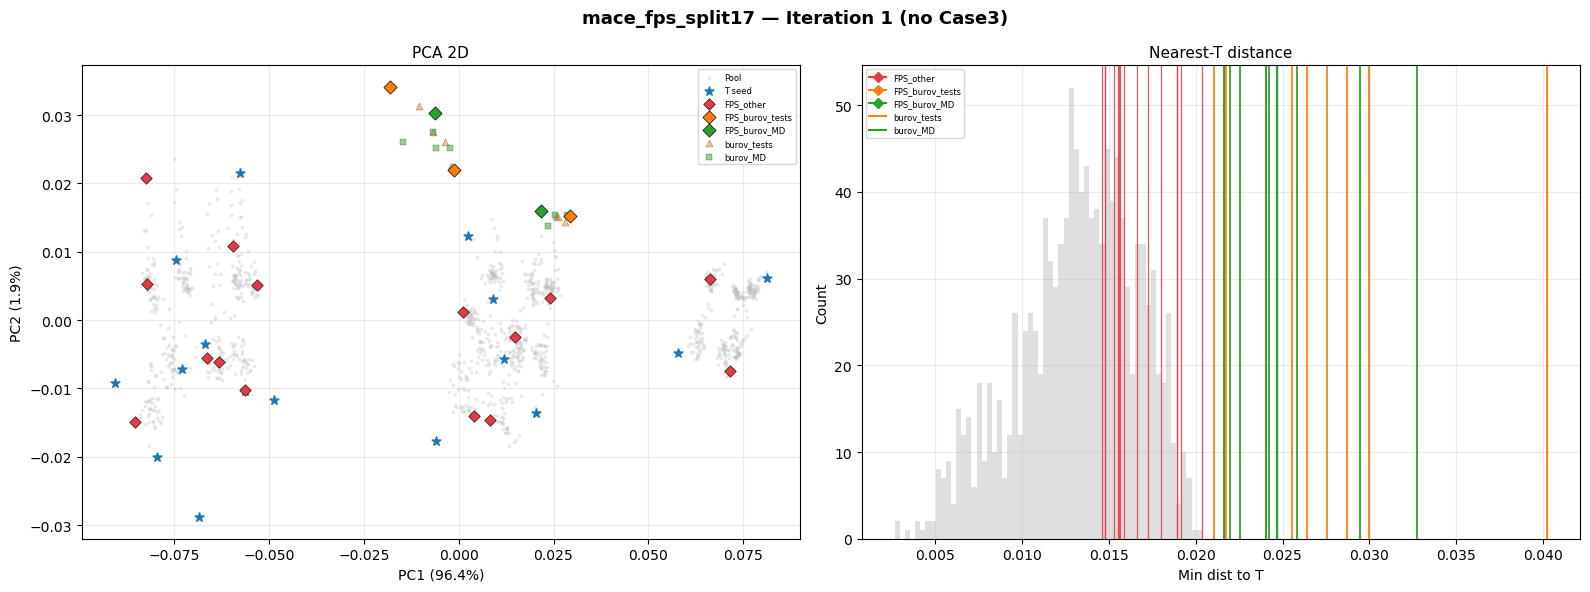

Saved → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17/it1_split17_coverage_overview_nocase3.png


In [13]:
EXTRA_ITER = EXTRA_NO_C3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("mace_fps_split17 — Iteration 1 (no Case3)",
             fontsize=13, fontweight="bold")

ax1.set_title("PCA 2D", fontsize=11)
ax1.scatter(emb_2d[idx_plot["pool"],0], emb_2d[idx_plot["pool"],1], **STYLE["pool"])
ax1.scatter(emb_2d[idx["T"],0],         emb_2d[idx["T"],1],         **STYLE["T"])
for lbl in ALL_FPS_LABELS:
    gi_arr = idx_plot[lbl]
    if len(gi_arr): ax1.scatter(emb_2d[gi_arr,0], emb_2d[gi_arr,1], **STYLE[lbl])
for g in EXTRA_ITER:
    if len(idx_plot[g]): ax1.scatter(emb_2d[idx_plot[g],0], emb_2d[idx_plot[g],1], **STYLE[g])
ax1.set_xlabel(f"PC1 ({var_2d[0]:.1f}%)"); ax1.set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
ax1.legend(fontsize=6); ax1.grid(True, alpha=0.25)

ax2.set_title("Nearest-T distance", fontsize=11)
ax2.hist(dist_pool, bins=60, color="#C0C0C0", alpha=0.5, label="pool")
for lbl in ALL_FPS_LABELS:
    if lbl in dist_fps:
        for d in dist_fps[lbl]:
            ax2.axvline(d, color=STYLE[lbl]["c"], lw=0.9, alpha=0.85)
for g in EXTRA_ITER:
    if g in dist_extra:
        for d in dist_extra[g]:
            ax2.axvline(d, color=STYLE[g]["c"], lw=1.4, alpha=0.9)
handles = ([mlines.Line2D([],[],color=STYLE[l]["c"],lw=1.5,marker="D",markersize=5,label=l)
            for l in ALL_FPS_LABELS if l in dist_fps]
         + [mlines.Line2D([],[],color=STYLE[g]["c"],lw=1.5,label=g)
            for g in EXTRA_ITER if g in dist_extra])
ax2.legend(handles=handles, fontsize=6)
ax2.set_xlabel("Min dist to T"); ax2.set_ylabel("Count"); ax2.grid(True, alpha=0.25)

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "it1_split17_coverage_overview_nocase3.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved → {out}")


## 12. Plot 2 — T Coverage Circles  (with Case3)

[INFO] annotate() not found → reinitializing


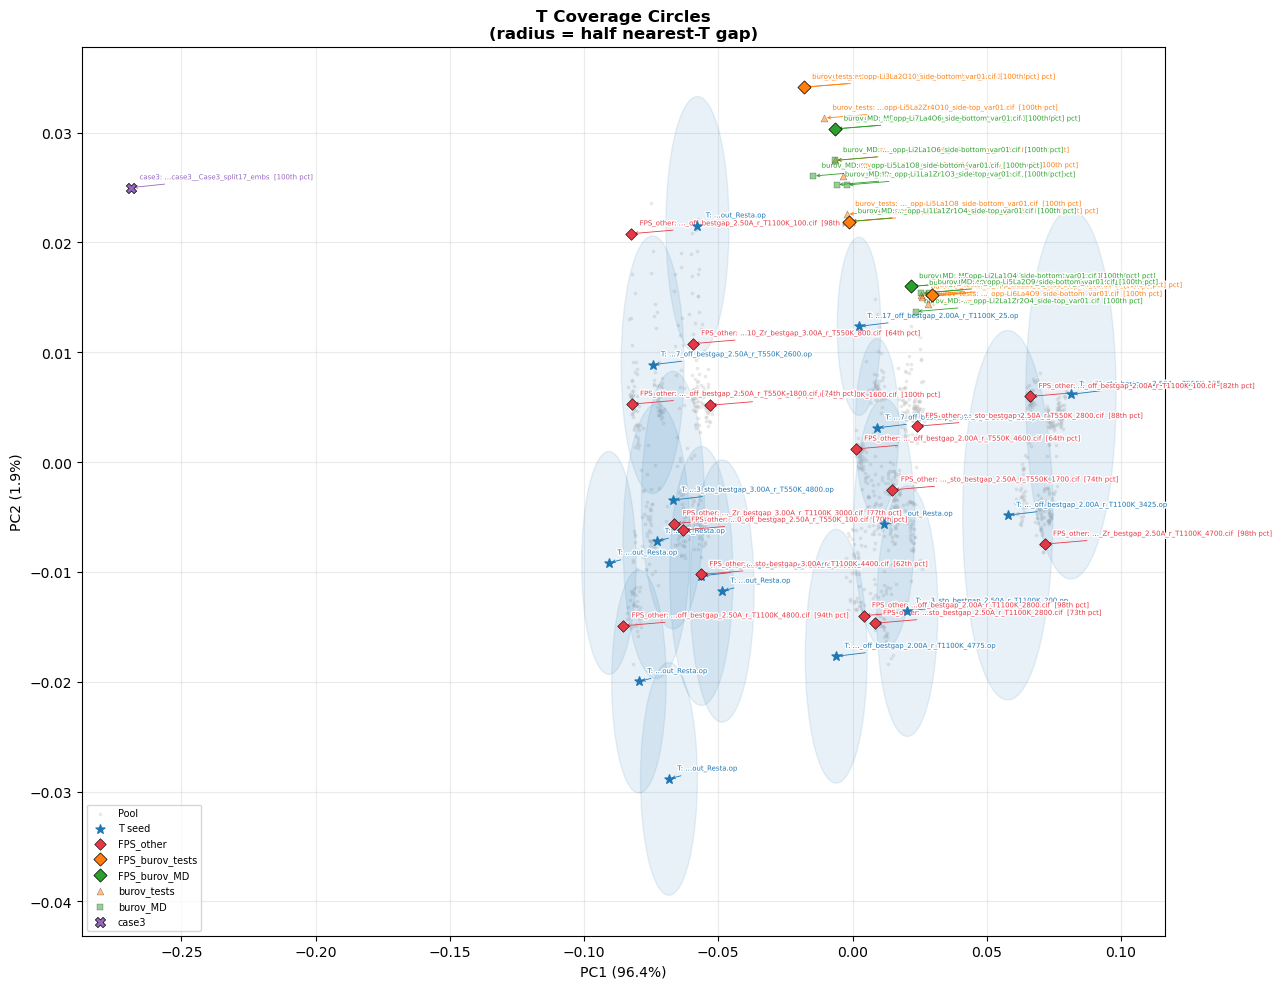

Saved → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17/it1_split17_T_radii.png


In [15]:
# --- SAFETY: ensure annotate exists ---
if "annotate" not in globals():
    print("[INFO] annotate() not found → reinitializing")

    import matplotlib.patheffects as pe
    import os

    def annotate(ax, gi, lbl, extra=""):
        stem = os.path.basename(filenames[gi])[-35:]
        txt = ax.annotate(
            f"{lbl}: …{stem}{extra}",
            xy=(emb_2d[gi,0], emb_2d[gi,1]),
            xytext=(6,6),
            textcoords="offset points",
            fontsize=5.0,
            color=STYLE[lbl]["c"],
            arrowprops=dict(
                arrowstyle="->",
                color=STYLE[lbl]["c"],
                lw=0.6
            )
        )
        txt.set_path_effects([
            pe.Stroke(linewidth=2, foreground="white"),
            pe.Normal()
        ])
EXTRA_ITER = ALL_EXTRA
fig2, ax3 = plt.subplots(figsize=(13, 10))
ax3.set_title("T Coverage Circles\n"
              "(radius = half nearest-T gap)", fontsize=12, fontweight="bold")
ax3.scatter(emb_2d[idx_plot["pool"],0], emb_2d[idx_plot["pool"],1], **STYLE["pool"])
D_TT = cdist(emb_T, emb_T); np.fill_diagonal(D_TT, np.inf); r_T = D_TT.min(axis=1)/2.
for ii, gi in enumerate(idx["T"]):
    ax3.add_patch(plt.Circle((emb_2d[gi,0], emb_2d[gi,1]), radius=r_T[ii],
                              color=STYLE["T"]["c"], alpha=0.10, zorder=2))
ax3.scatter(emb_2d[idx["T"],0], emb_2d[idx["T"],1], **STYLE["T"])
for gi in idx["T"]: annotate(ax3, gi, "T")
# FPS groups — one scatter per label, then annotate
for lbl in ALL_FPS_LABELS:
    gi_arr = idx_plot[lbl]
    if not len(gi_arr): continue
    ax3.scatter(emb_2d[gi_arr,0], emb_2d[gi_arr,1], **STYLE[lbl])
    for gi in gi_arr:
        _d = cdist(emb_hd[gi:gi+1], emb_T).min()
        _p = pool_pct(np.array([_d]))[0]
        annotate(ax3, gi, lbl, f"  [{_p:.0f}th pct]")
for g in EXTRA_ITER:
    gi_arr = idx_plot[g]
    if not len(gi_arr): continue
    ax3.scatter(emb_2d[gi_arr,0], emb_2d[gi_arr,1], **STYLE[g])
    for k, gi in enumerate(gi_arr):
        pct_val = pct_extra[g][k] if g in pct_extra else 0
        annotate(ax3, gi, g, f"  [{pct_val:.0f}th pct]")
ax3.set_xlabel(f"PC1 ({var_2d[0]:.1f}%)"); ax3.set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
ax3.legend(fontsize=7); ax3.grid(True, alpha=0.25)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "it1_split17_T_radii.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved → {out}")


### Plot 2  (no Case3)

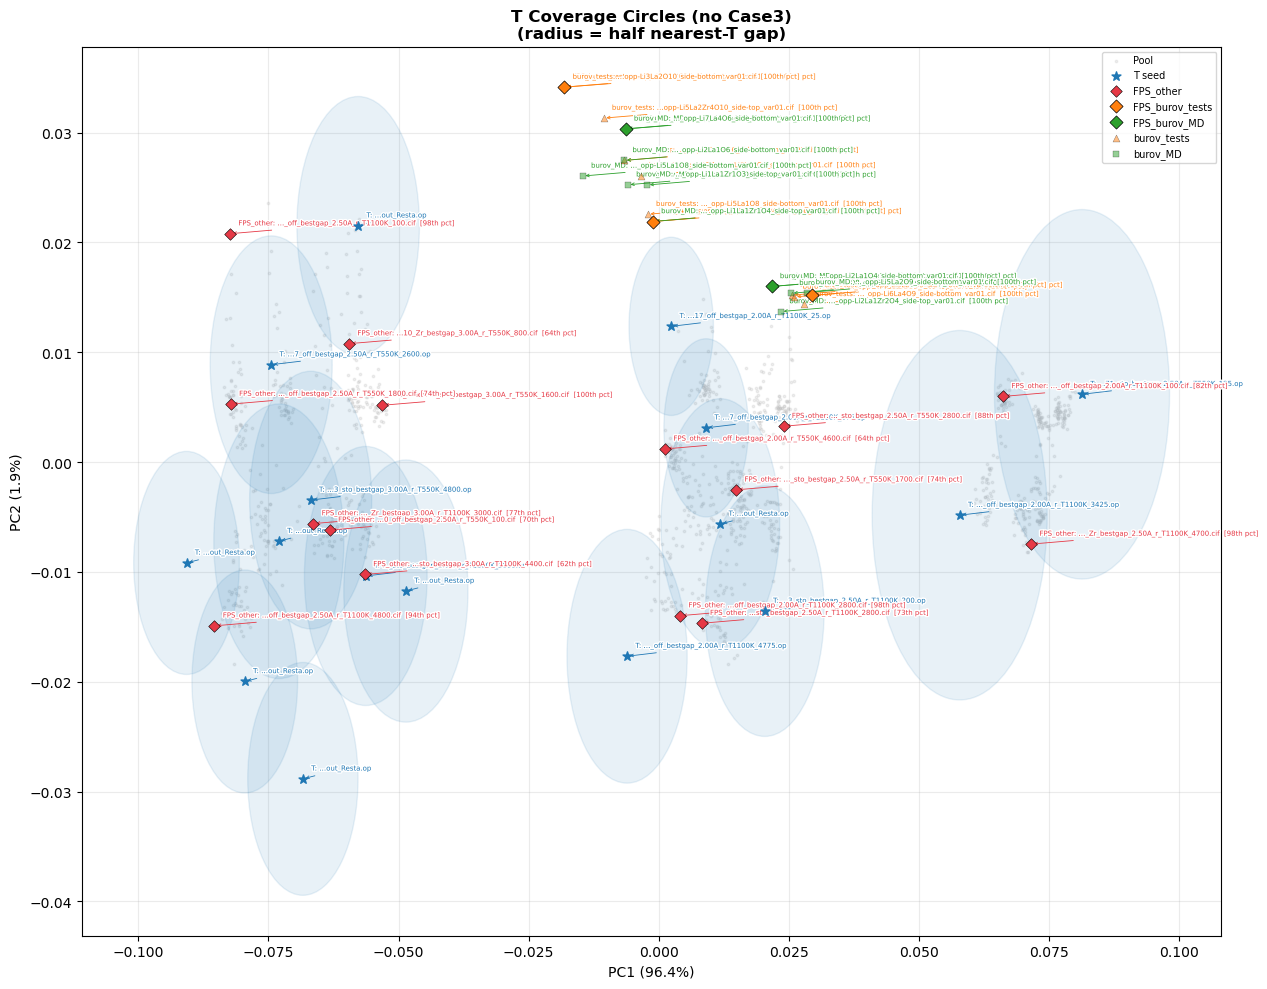

Saved → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17/it1_split17_T_radii_nocase3.png


In [16]:
EXTRA_ITER = EXTRA_NO_C3
fig2, ax3 = plt.subplots(figsize=(13, 10))
ax3.set_title("T Coverage Circles (no Case3)\n"
              "(radius = half nearest-T gap)", fontsize=12, fontweight="bold")
ax3.scatter(emb_2d[idx_plot["pool"],0], emb_2d[idx_plot["pool"],1], **STYLE["pool"])
D_TT = cdist(emb_T, emb_T); np.fill_diagonal(D_TT, np.inf); r_T = D_TT.min(axis=1)/2.
for ii, gi in enumerate(idx["T"]):
    ax3.add_patch(plt.Circle((emb_2d[gi,0], emb_2d[gi,1]), radius=r_T[ii],
                              color=STYLE["T"]["c"], alpha=0.10, zorder=2))
ax3.scatter(emb_2d[idx["T"],0], emb_2d[idx["T"],1], **STYLE["T"])
for gi in idx["T"]: annotate(ax3, gi, "T")
# FPS groups — one scatter per label, then annotate
for lbl in ALL_FPS_LABELS:
    gi_arr = idx_plot[lbl]
    if not len(gi_arr): continue
    ax3.scatter(emb_2d[gi_arr,0], emb_2d[gi_arr,1], **STYLE[lbl])
    for gi in gi_arr:
        _d = cdist(emb_hd[gi:gi+1], emb_T).min()
        _p = pool_pct(np.array([_d]))[0]
        annotate(ax3, gi, lbl, f"  [{_p:.0f}th pct]")
for g in EXTRA_ITER:
    gi_arr = idx_plot[g]
    if not len(gi_arr): continue
    ax3.scatter(emb_2d[gi_arr,0], emb_2d[gi_arr,1], **STYLE[g])
    for k, gi in enumerate(gi_arr):
        pct_val = pct_extra[g][k] if g in pct_extra else 0
        annotate(ax3, gi, g, f"  [{pct_val:.0f}th pct]")
ax3.set_xlabel(f"PC1 ({var_2d[0]:.1f}%)"); ax3.set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
ax3.legend(fontsize=7); ax3.grid(True, alpha=0.25)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "it1_split17_T_radii_nocase3.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved → {out}")


## 13. Plot 3 — CDF  (with Case3)

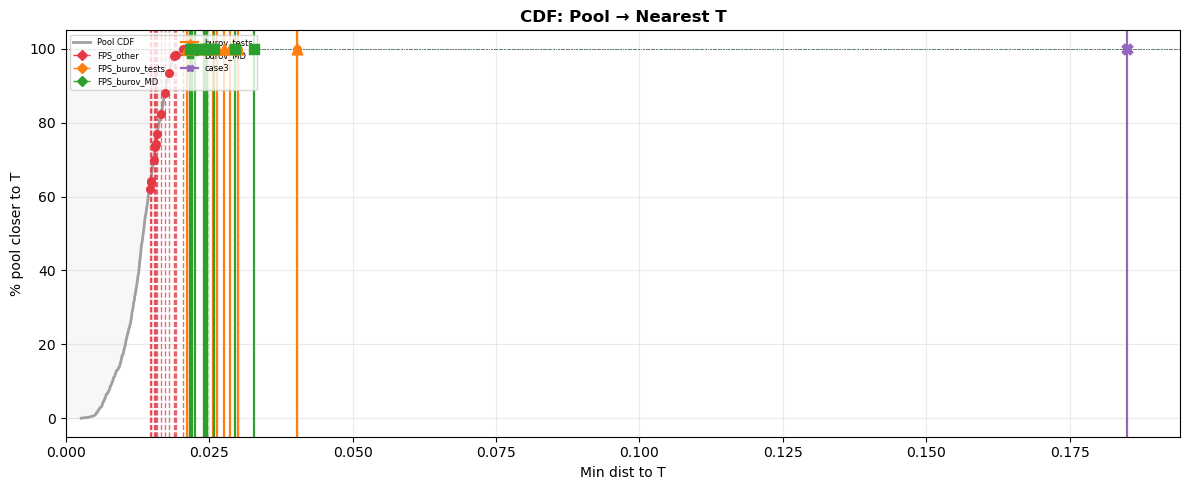

Saved → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17/it1_split17_cdf.png


In [17]:
EXTRA_ITER = ALL_EXTRA
s_pool = np.sort(dist_pool); cdf_y = np.linspace(0,100,len(s_pool))
fig3, ax4 = plt.subplots(figsize=(12,5))
ax4.set_title("CDF: Pool → Nearest T", fontsize=12, fontweight="bold")
ax4.plot(s_pool, cdf_y, color="#A0A0A0", lw=2, label="Pool CDF")
ax4.fill_betweenx(cdf_y, s_pool, alpha=0.08, color="#A0A0A0")
for lbl in ALL_FPS_LABELS:
    if lbl not in dist_fps: continue
    for d, p in zip(dist_fps[lbl], pct_fps[lbl]):
        ax4.axvline(d, color=STYLE[lbl]["c"], lw=1.0, linestyle="--", alpha=0.75)
        ax4.scatter([d],[p], color=STYLE[lbl]["c"], s=30, zorder=6)
for g in EXTRA_ITER:
    if g not in dist_extra: continue
    for d, p in zip(dist_extra[g], pct_extra[g]):
        ax4.axvline(d, color=STYLE[g]["c"], lw=1.6)
        ax4.axhline(p, color=STYLE[g]["c"], lw=0.7, linestyle=":")
        ax4.scatter([d],[p], color=STYLE[g]["c"], marker=STYLE[g]["marker"], s=60, zorder=7)
legend_h = ([plt.Line2D([],[],color="#A0A0A0",lw=2,label="Pool CDF")]
           + [mlines.Line2D([],[],color=STYLE[l]["c"],lw=1,linestyle="--",marker="D",
                             markersize=5,label=l) for l in ALL_FPS_LABELS if l in dist_fps]
           + [mlines.Line2D([],[],color=STYLE[g]["c"],lw=1.6,marker=STYLE[g]["marker"],
                             markersize=5,label=g) for g in EXTRA_ITER if g in dist_extra])
ax4.legend(handles=legend_h, fontsize=6, ncol=2, loc="upper left")
ax4.set_xlabel("Min dist to T"); ax4.set_ylabel("% pool closer to T")
ax4.grid(True, alpha=0.25); ax4.set_xlim(left=0)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "it1_split17_cdf.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved → {out}")


### Plot 3  (no Case3)

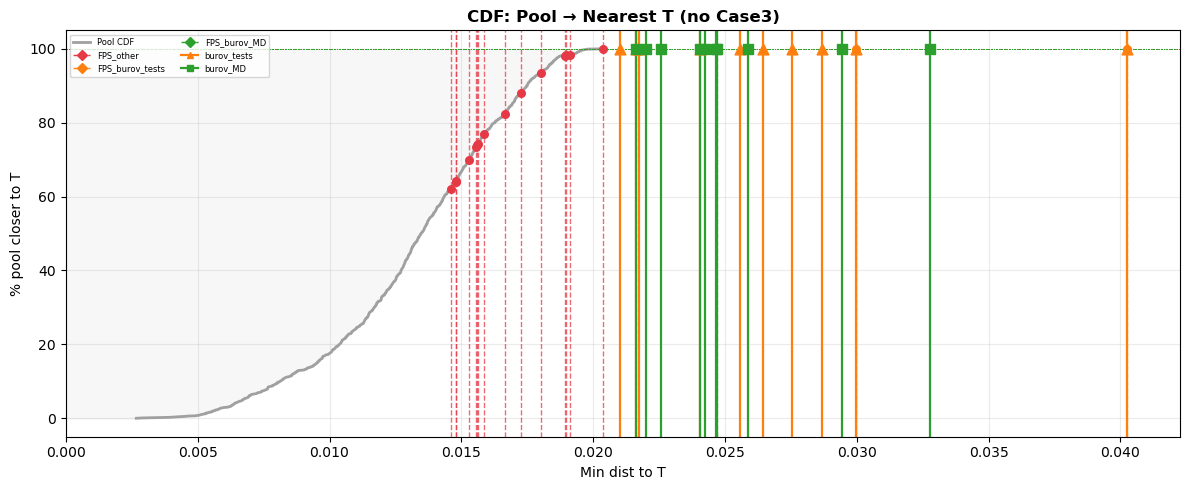

Saved → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17/it1_split17_cdf_nocase3.png


In [18]:
EXTRA_ITER = EXTRA_NO_C3
s_pool = np.sort(dist_pool); cdf_y = np.linspace(0,100,len(s_pool))
fig3, ax4 = plt.subplots(figsize=(12,5))
ax4.set_title("CDF: Pool → Nearest T (no Case3)", fontsize=12, fontweight="bold")
ax4.plot(s_pool, cdf_y, color="#A0A0A0", lw=2, label="Pool CDF")
ax4.fill_betweenx(cdf_y, s_pool, alpha=0.08, color="#A0A0A0")
for lbl in ALL_FPS_LABELS:
    if lbl not in dist_fps: continue
    for d, p in zip(dist_fps[lbl], pct_fps[lbl]):
        ax4.axvline(d, color=STYLE[lbl]["c"], lw=1.0, linestyle="--", alpha=0.75)
        ax4.scatter([d],[p], color=STYLE[lbl]["c"], s=30, zorder=6)
for g in EXTRA_ITER:
    if g not in dist_extra: continue
    for d, p in zip(dist_extra[g], pct_extra[g]):
        ax4.axvline(d, color=STYLE[g]["c"], lw=1.6)
        ax4.axhline(p, color=STYLE[g]["c"], lw=0.7, linestyle=":")
        ax4.scatter([d],[p], color=STYLE[g]["c"], marker=STYLE[g]["marker"], s=60, zorder=7)
legend_h = ([plt.Line2D([],[],color="#A0A0A0",lw=2,label="Pool CDF")]
           + [mlines.Line2D([],[],color=STYLE[l]["c"],lw=1,linestyle="--",marker="D",
                             markersize=5,label=l) for l in ALL_FPS_LABELS if l in dist_fps]
           + [mlines.Line2D([],[],color=STYLE[g]["c"],lw=1.6,marker=STYLE[g]["marker"],
                             markersize=5,label=g) for g in EXTRA_ITER if g in dist_extra])
ax4.legend(handles=legend_h, fontsize=6, ncol=2, loc="upper left")
ax4.set_xlabel("Min dist to T"); ax4.set_ylabel("% pool closer to T")
ax4.grid(True, alpha=0.25); ax4.set_xlim(left=0)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "it1_split17_cdf_nocase3.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved → {out}")


## 14. Cluster-Aware Selection — Super-Representatives
Secondary FPS on all 20 FPS picks → 6 representatives that minimise DFT calls.

In [19]:
emb_fps = emb_hd[fps_global_idx]

def secondary_fps(embs, n):
    centroid = embs.mean(axis=0)
    first    = int(np.argmax(np.linalg.norm(embs - centroid, axis=1)))
    sel = [first]; min_d = np.linalg.norm(embs - embs[first], axis=1).copy()
    min_d[first] = -np.inf
    for _ in range(n-1):
        pick = int(np.argmax(min_d)); sel.append(pick)
        d = np.linalg.norm(embs - embs[pick], axis=1)
        min_d = np.minimum(min_d, d); min_d[pick] = -np.inf
    return np.array(sel)

super_local  = secondary_fps(emb_fps, N_SUPER)
super_global = fps_global_idx[super_local]

D_super = cdist(emb_fps[super_local], emb_fps[super_local])
np.fill_diagonal(D_super, np.inf)
r_super = D_super.min(axis=1) / 2.0

dist_fps_to_super  = cdist(emb_fps, emb_fps[super_local])
dist_pool_to_super = cdist(emb_hd[idx["pool"]], emb_fps[super_local])

rows = []
print(f"{'#':<3} {'PC1':>7} {'PC2':>7} {'r_inf':>7} {'FPS_cov':>8} {'Pool_cov':>9}  Origin  Stem")
print("-"*95)
for k, (sl, sg) in enumerate(zip(super_local, super_global)):
    r   = r_super[k]
    fps_cov  = int((dist_fps_to_super[:,k] <= r).sum()) - 1
    pool_cov = int((dist_pool_to_super[:,k] <= r).sum())
    pc1, pc2 = emb_2d[sg]
    stem     = os.path.basename(filenames[sg])
    orig     = labels_arr[sg]
    print(f"{k+1:<3} {pc1:>7.3f} {pc2:>7.3f} {r:>7.4f} {fps_cov:>8d} {pool_cov:>9d}  [{orig}] {stem}")
    rows.append(dict(Rank=k+1,PC1=pc1,PC2=pc2,r_influence=r,
                     FPS_other_covered=fps_cov,Pool_covered=pool_cov,Origin=orig,Stem=stem))
    members = [j for j in range(len(fps_global_idx))
               if dist_fps_to_super[j,k] <= r and j != sl]
    for j in members:
        print(f"     ↳ [{labels_arr[fps_global_idx[j]]}] {os.path.basename(filenames[fps_global_idx[j]])}")

df_super = pd.DataFrame(rows)
df_super.to_csv(os.path.join(OUTPUT_DIR,"it1_split17_super_reps.csv"), index=False)
print(f"\nSaved super_reps.csv")


#       PC1     PC2   r_inf  FPS_cov  Pool_cov  Origin  Stem
-----------------------------------------------------------------------------------------------
1     0.072  -0.007  0.0254        1       300  [pool] Li_111_slab__LLZO_110_Zr_bestgap_2.50A_r_T1100K_4700.cif
     ↳ [pool] Li_111_slab__LLZO_110_Li_order17_off_bestgap_2.00A_r_T1100K_100.cif
2    -0.085  -0.015  0.0196        0        89  [pool] Li_100_slab__LLZO_010_La_order0_off_bestgap_2.50A_r_T1100K_4800.cif
3    -0.018   0.034  0.0293        1         0  [burov_tests] burov_tests__Li_LLZO_110_ct-Li5La2Zr4O8_opp-Li3La2O10_side-bottom_var01.cif
     ↳ [burov_MD] burov_MD__Li_LLZO_110_ct-Li1Zr1O2_opp-Li7La4O6_side-bottom_var01.cif
4     0.004  -0.014  0.0207        3       292  [pool] Li_110_slab__LLZO_010_La_order0_off_bestgap_2.00A_r_T1100K_2800.cif
     ↳ [pool] Li_110_slab__LLZO_001_Zr_code93_sto_bestgap_2.50A_r_T550K_1700.cif
     ↳ [pool] Li_110_slab__LLZO_001_Zr_code93_sto_bestgap_2.50A_r_T1100K_2800.cif
     ↳ [pool] L

### Super-Rep Plot

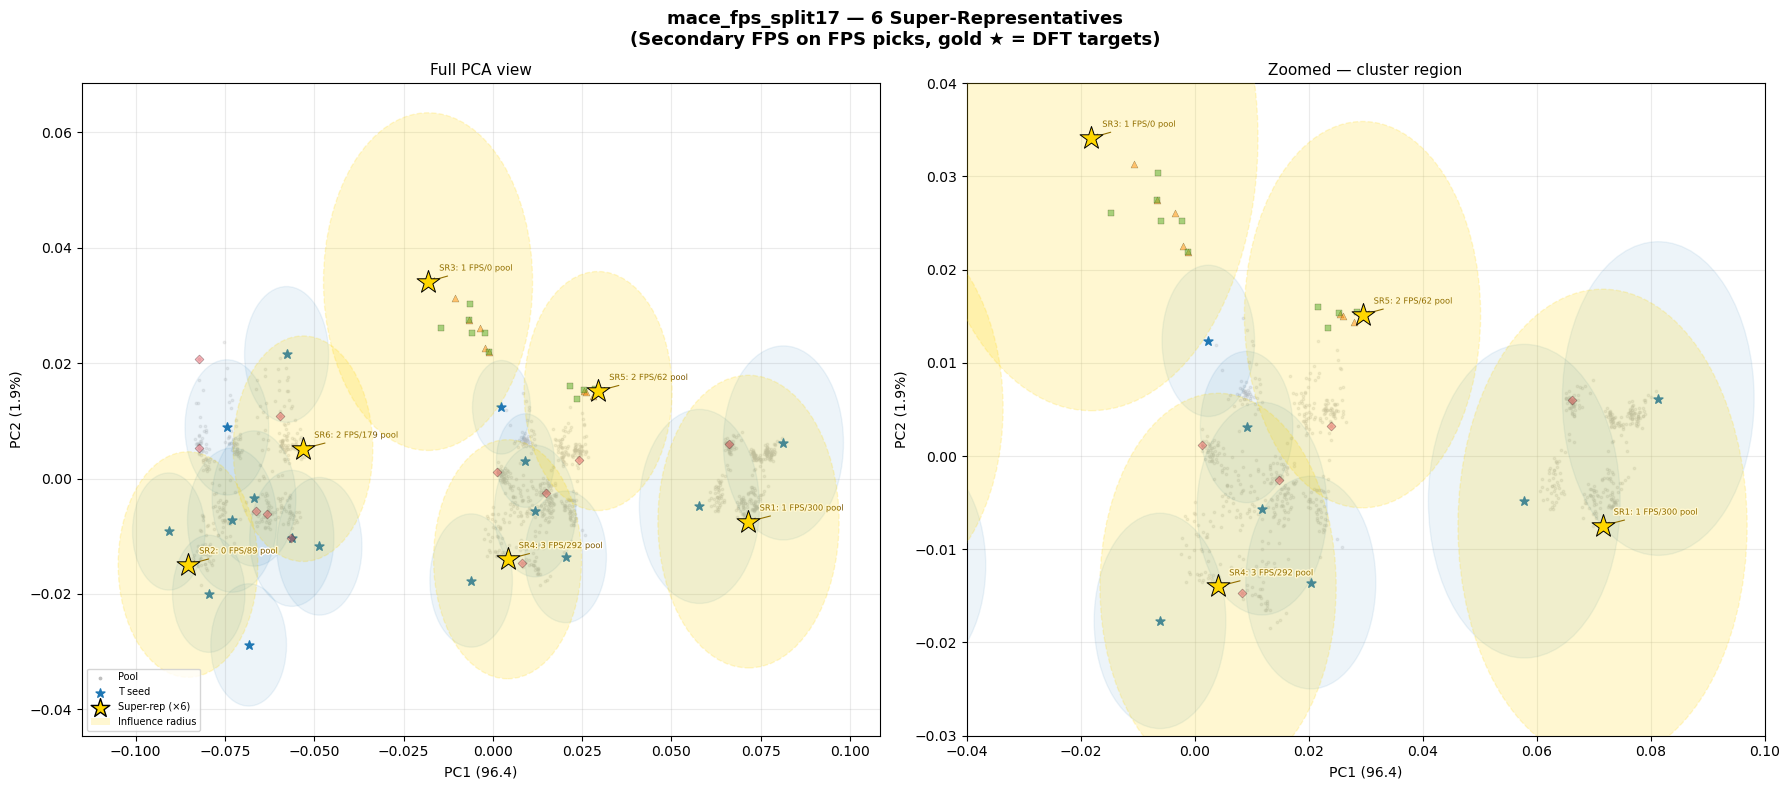

Saved → /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17/it1_split17_super_reps.png


In [20]:
SUPER_COLOR = "#FFD700"
D_TT = cdist(emb_T, emb_T); np.fill_diagonal(D_TT, np.inf); r_T = D_TT.min(axis=1)/2.

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("mace_fps_split17 — 6 Super-Representatives\n"
             "(Secondary FPS on FPS picks, gold ★ = DFT targets)",
             fontsize=13, fontweight="bold")

for ax, zoom in zip(axes, [False, True]):
    ax.scatter(emb_2d[idx_plot["pool"],0], emb_2d[idx_plot["pool"],1], **STYLE["pool"])
    for ii, gi in enumerate(idx["T"]):
        ax.add_patch(plt.Circle((emb_2d[gi,0], emb_2d[gi,1]), radius=r_T[ii],
                                 color=STYLE["T"]["c"], alpha=0.08, zorder=2))
    ax.scatter(emb_2d[idx["T"],0], emb_2d[idx["T"],1], **STYLE["T"])
    # non-super FPS
    ns_mask = np.ones(len(fps_global_idx), dtype=bool); ns_mask[super_local] = False
    for lbl in ALL_FPS_LABELS:
        gi_ns = np.array([fps_global_idx[j] for j in range(len(fps_global_idx))
                          if ns_mask[j] and labels_plot[fps_global_idx[j]] == lbl])
        if len(gi_ns):
            kw = dict(STYLE[lbl]); kw["s"] = kw["s"]*0.6; kw["alpha"] = 0.4; kw["label"] = "_nolegend_"
            ax.scatter(emb_2d[gi_ns,0], emb_2d[gi_ns,1], **kw)
    # burov unselected
    for g in EXTRA_NO_C3:
        gi_arr = idx_plot[g]
        if len(gi_arr): ax.scatter(emb_2d[gi_arr,0], emb_2d[gi_arr,1], **STYLE[g])
    # super reps
    for k, (sl, sg) in enumerate(zip(super_local, super_global)):
        r = r_super[k]
        ax.add_patch(plt.Circle((emb_2d[sg,0], emb_2d[sg,1]), radius=r,
                                  color=SUPER_COLOR, alpha=0.18, zorder=5, linestyle="--", fill=True))
        ax.scatter(emb_2d[sg,0], emb_2d[sg,1], c=SUPER_COLOR, marker="*", s=300, zorder=9,
                   edgecolors="k", linewidths=0.7)
        fps_cov  = df_super.loc[k,"FPS_other_covered"]
        pool_cov = df_super.loc[k,"Pool_covered"]
        txt = ax.annotate(f"SR{k+1}: {fps_cov} FPS/{pool_cov} pool",
            xy=(emb_2d[sg,0], emb_2d[sg,1]), xytext=(8,8), textcoords="offset points",
            fontsize=6, color="#7B5800",
            arrowprops=dict(arrowstyle="->", color="#7B5800", lw=0.8))
        txt.set_path_effects([pe.Stroke(linewidth=2, foreground="white"), pe.Normal()])

    ax.set_xlabel(f"PC1 ({var_2d[0]:.1f})"); ax.set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
    ax.grid(True, alpha=0.25)
    if zoom:
        ax.set_xlim(-0.04, 0.10); ax.set_ylim(-0.03, 0.04)
        ax.set_title("Zoomed — cluster region", fontsize=11)
    else:
        ax.set_title("Full PCA view", fontsize=11)

legend_els = [
    plt.scatter([],[],c="#C0C0C0",s=3,label="Pool"),
    plt.scatter([],[],c="#1F77B4",marker="*",s=45,label="T seed"),
    plt.scatter([],[],c=SUPER_COLOR,marker="*",s=200,edgecolors="k",label=f"Super-rep (×{N_SUPER})"),
    Patch(facecolor=SUPER_COLOR,alpha=0.18,label="Influence radius"),
]
axes[0].legend(handles=legend_els, fontsize=7, loc="lower left")
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "it1_split17_super_reps.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved → {out}")


Coverage Analysis of these super reps

In [22]:
print("\n" + "="*60)
print("SUPER-REP JUSTIFICATION METRICS")
print("="*60)

# --- 1. FPS coverage (how many of the 20 are represented) ---
covered_fps = (cdist(emb_fps, emb_fps[super_local]).min(axis=1)
               <= np.max(r_super)).sum()

print(f"\n1. FPS COVERAGE")
print(f"   Total FPS points        : {len(emb_fps)}")
print(f"   Covered by 6 reps       : {covered_fps}")
print(f"   Coverage %              : {100*covered_fps/len(emb_fps):.1f}%")

# --- 2. Mean distance comparison ---
dist_fps_to_super = cdist(emb_fps, emb_fps[super_local]).min(axis=1)

print(f"\n2. REPRESENTATION QUALITY")
print(f"   Mean dist (FPS → nearest super-rep): {dist_fps_to_super.mean():.4f}")
print(f"   Max  dist (worst-case error)      : {dist_fps_to_super.max():.4f}")

# --- 3. Compare against original T ---
dist_fps_to_T = cdist(emb_fps, emb_T).min(axis=1)

print(f"\n3. IMPROVEMENT OVER ORIGINAL TRAINING")
print(f"   Mean dist to T         : {dist_fps_to_T.mean():.4f}")
print(f"   Mean dist to super-rep : {dist_fps_to_super.mean():.4f}")
print(f"   Reduction              : {100*(1 - dist_fps_to_super.mean()/dist_fps_to_T.mean()):.1f}%")

# --- 4. Pool coverage retained ---
dist_pool_to_super = cdist(emb_hd[idx["pool"]], emb_fps[super_local]).min(axis=1)

print(f"\n4. POOL COVERAGE")
print(f"   Mean dist (pool → super-reps): {dist_pool_to_super.mean():.4f}")

# Compare to full FPS
dist_pool_to_fps = cdist(emb_hd[idx["pool"]], emb_fps).min(axis=1)

print(f"   Mean dist (pool → all 20 FPS): {dist_pool_to_fps.mean():.4f}")
print(f"   Degradation from compression : {100*(dist_pool_to_super.mean()/dist_pool_to_fps.mean() - 1):.1f}%")

# --- 5. Redundancy (this is KEY) ---
D_fps_fps = cdist(emb_fps, emb_fps)
np.fill_diagonal(D_fps_fps, np.inf)

print(f"\n5. REDUNDANCY IN FPS SET")
print(f"   Mean nearest-neighbor distance (within FPS): {D_fps_fps.min(axis=1).mean():.4f}")

print("="*60)


SUPER-REP JUSTIFICATION METRICS

1. FPS COVERAGE
   Total FPS points        : 20
   Covered by 6 reps       : 18
   Coverage %              : 90.0%

2. REPRESENTATION QUALITY
   Mean dist (FPS → nearest super-rep): 0.0151
   Max  dist (worst-case error)      : 0.0386

3. IMPROVEMENT OVER ORIGINAL TRAINING
   Mean dist to T         : 0.0196
   Mean dist to super-rep : 0.0151
   Reduction              : 22.9%

4. POOL COVERAGE
   Mean dist (pool → super-reps): 0.0153
   Mean dist (pool → all 20 FPS): 0.0086
   Degradation from compression : 77.2%

5. REDUNDANCY IN FPS SET
   Mean nearest-neighbor distance (within FPS): 0.0175


## 15. Summary & CSV Export

In [21]:
print("══ COVERAGE SUMMARY (Iteration 1 / split-17) ══")
print(f"  Pool             : {len(dist_pool)}")
print(f"  T seed           : {len(idx['T'])}")
for lbl in ALL_FPS_LABELS:
    n = len(idx_plot[lbl])
    if n: print(f"  {lbl:<22}: {n}")
print(f"  FPS total        : {len(fps_global_idx)}")
print(f"  Pool mean dist   : {dist_pool.mean():.4f}")
for lbl in ALL_FPS_LABELS:
    if lbl in dist_fps:
        print(f"  {lbl:<22}: mean={dist_fps[lbl].mean():.4f}  pct={pct_fps[lbl].mean():.1f}th")
print("="*50)

df_fps.to_csv(os.path.join(OUTPUT_DIR,"it1_split17_fps_selected.csv"), index=False)
pd.DataFrame({
    "Stem": [os.path.basename(filenames[i]) for i in idx["pool"]],
    "Dist_to_nearest_T": dist_pool,
    "Percentile_vs_pool": pool_pct(dist_pool),
}).sort_values("Dist_to_nearest_T",ascending=False).to_csv(
    os.path.join(OUTPUT_DIR,"it1_split17_pool_coverage.csv"), index=False)
pd.DataFrame([{"Label":"T","Stem":os.path.basename(filenames[gi]),
               "Filename":filenames[gi]} for gi in idx["T"]]).to_csv(
    os.path.join(OUTPUT_DIR,"it1_split17_T_seed.csv"), index=False)
print(f"CSVs saved to {OUTPUT_DIR}")


══ COVERAGE SUMMARY (Iteration 1 / split-17) ══
  Pool             : 1200
  T seed           : 16
  FPS_other             : 15
  FPS_burov_tests       : 3
  FPS_burov_MD          : 2
  FPS total        : 20
  Pool mean dist   : 0.0132
  FPS_other             : mean=0.0168  pct=81.1th
  FPS_burov_tests       : mean=0.0306  pct=100.0th
  FPS_burov_MD          : mean=0.0247  pct=100.0th
CSVs saved to /home/mehuldarak/athena/structure_level_latents/fps_coverage_it1_split17
